In [42]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


In [43]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('spaceship-titanic')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/spaceship-titanic


In [44]:
!pip install tensorflow==2.19.0
!pip3 install tensorflow_decision_forests --upgrade

import tensorflow as tf
import tensorflow_decision_forests as tfdf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("TensorFlow v" + tf.__version__)
print("TensorFlow Decision Forests v" + tfdf.__version__)

TensorFlow v2.19.0
TensorFlow Decision Forests v1.12.0


In [45]:
import tensorflow_decision_forests as tfdf
print(tfdf)

<module 'tensorflow_decision_forests' from '/usr/local/lib/python3.12/dist-packages/tensorflow_decision_forests/__init__.py'>


In [46]:
print("TensorFlow v" + tf.__version__)
print("TensorFlow Decision Forests v" + tfdf.__version__)

TensorFlow v2.19.0
TensorFlow Decision Forests v1.12.0


### Load the Dataset

In [47]:
dataset_df = pd.read_csv(path + '/train.csv')
print("Full train dataset shape is {}".format(dataset_df.shape))

Full train dataset shape is (8693, 14)


In [48]:
dataset_df.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [49]:
dataset_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [50]:
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


<Axes: xlabel='Transported'>

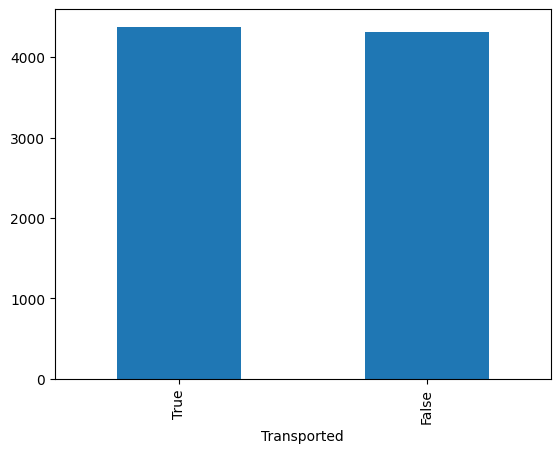

In [51]:
plot_df = dataset_df.Transported.value_counts()
plot_df.plot(kind="bar")

### Numerical data distribution

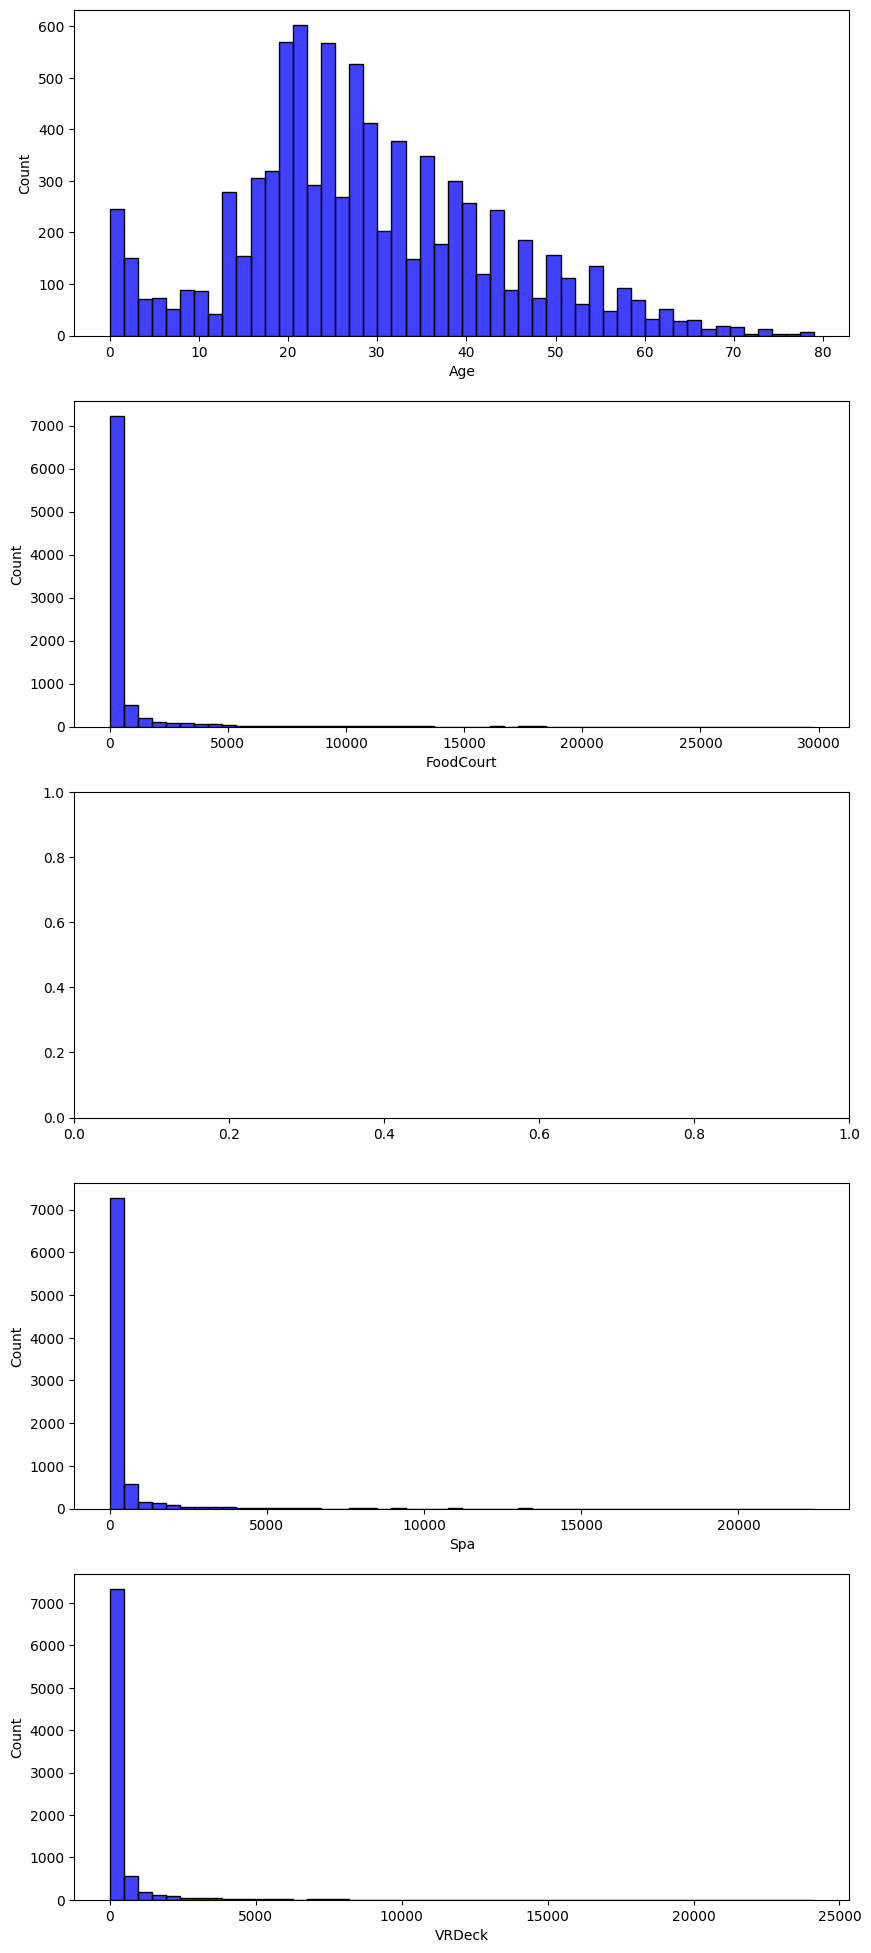

In [52]:
fig, ax = plt.subplots(5,1, figsize=(10,10))
plt.subplots_adjust(top=2)

sns.histplot(dataset_df['Age'], color='b', bins=50, ax=ax[0]);
sns.histplot(dataset_df['FoodCourt'], color='b', bins=50, ax=ax[1]);
sns.histplot(dataset_df['Spa'], color='b', bins=50, ax=ax[3]);
sns.histplot(dataset_df['VRDeck'], color='b', bins=50, ax=ax[4]);

### Prepare the dataset

In [53]:
dataset_df =dataset_df.drop(['PassengerId','Name'], axis=1)
dataset_df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [54]:
dataset_df.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
Transported       0
dtype: int64

In [55]:
dataset_df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = dataset_df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)

dataset_df.isnull().sum().sort_values(ascending=False)

HomePlanet      201
Cabin           199
Destination     182
RoomService     181
Age             179
CryoSleep         0
VIP               0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
dtype: int64

In [56]:
label = "Transported"
dataset_df[label]=dataset_df[label].astype(int)

In [57]:
dataset_df['VIP'] = dataset_df['VIP'].astype(int)
dataset_df['CryoSleep'] = dataset_df['CryoSleep'].astype(int)

In [58]:
dataset_df[["Deck", "Cabin_num","Side"]] = dataset_df["Cabin"].str.split("/",expand=True)
dataset_df[["Deck", "Cabin_num","Side"]].head(5)

,Deck,Cabin_num,Side
0,B,0,P
1,F,0,S
2,A,0,S
3,A,0,S
4,F,1,S


In [59]:
try:
    dataset_df=dataset_df.drop('Cabin', axis=1)
except KeyError:
    print("Field does not exist")

In [60]:
def split_dataset(dataset, test_ratio=0.20):
    test_indices = np.random.rand(len(dataset)) < test_ratio
    return dataset[~test_indices], dataset[test_indices]

train_ds_pd, valid_ds_pd = split_dataset(dataset_df)
print("{} examples in training, {} examples in testing.".format(len(train_ds_pd), len(valid_ds_pd)))

6928 examples in training, 1765 examples in testing.


In [61]:
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(train_ds_pd, label = label)

valid_ds = tfdf.keras.pd_dataframe_to_tf_dataset(valid_ds_pd, label = label)

### Select a Model

There are several tree-based models for you to choose from.

RandomForestModel
GradientBoostedTreesModel
CartModel
Distribution

In [62]:
tfdf.keras.get_all_models()

[tensorflow_decision_forests.keras.RandomForestModel,
 tensorflow_decision_forests.keras.GradientBoostedTreesModel,
 tensorflow_decision_forests.keras.CartModel,
 tensorflow_decision_forests.keras.DistributedGradientBoostedTreesModel]

In [63]:
rf = tfdf.keras.RandomForestModel(hyperparameter_template="benchmark_rank1")

Resolve hyper-parameter template "benchmark_rank1" to "benchmark_rank1@v1" -> {'winner_take_all': True, 'categorical_algorithm': 'RANDOM', 'split_axis': 'SPARSE_OBLIQUE', 'sparse_oblique_normalization': 'MIN_MAX', 'sparse_oblique_num_projections_exponent': 1.0}.
Use /tmp/tmpv3k3zp65 as temporary training directory


In [64]:
rf = tfdf.keras.RandomForestModel()
rf.compile(metrics=["accurancy"])

Use /tmp/tmp43qftl91 as temporary training directory


In [65]:
rf.fit(x=train_ds)    

Reading training dataset...
Training dataset read in 0:00:00.338145. Found 6928 examples.
Training model...


I0000 00:00:1790171728.553433      58 kernel.cc:782] Start Yggdrasil model training
I0000 00:00:1790171728.553485      58 kernel.cc:783] Collect training examples
I0000 00:00:1790171728.553500      58 kernel.cc:795] Dataspec guide:
column_guides {
  column_name_pattern: "^__LABEL$"
  type: CATEGORICAL
  categorial {
    min_vocab_frequency: 0
    max_vocab_count: -1
  }
}
default_column_guide {
  categorial {
    max_vocab_count: 2000
  }
  discretized_numerical {
    maximum_num_bins: 255
  }
}
ignore_columns_without_guides: false
detect_numerical_as_discretized_numerical: false

I0000 00:00:1790171728.553633      58 kernel.cc:401] Number of batches: 7
I0000 00:00:1790171728.553643      58 kernel.cc:402] Number of examples: 6928
I0000 00:00:1790171728.556691      58 data_spec_inference.cc:354] 1279 item(s) have been pruned (i.e. they are considered out of dictionary) for the column Cabin_num (469 item(s) left) because min_value_count=5 and max_number_of_unique_values=2000
I0000 00:00:

Model trained in 0:00:50.051335
Compiling model...


I0000 00:00:1790171778.542232      58 decision_forest.cc:808] Model loaded with 300 root(s), 232464 node(s), and 13 input feature(s).
I0000 00:00:1790171778.542332      58 abstract_model.cc:1439] Engine "RandomForestGeneric" built


Model compiled.


In [66]:
tfdf.model_plotter.plot_model_in_colab(rf, tree_idx=0, max_depth=3)

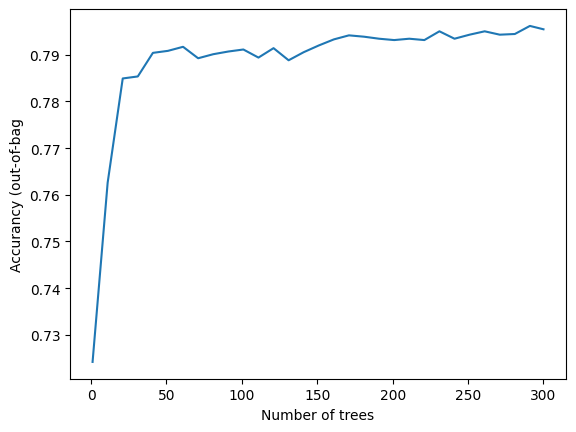

In [67]:
import matplotlib.pyplot as plt

logs=rf.make_inspector().training_logs()
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accurancy (out-of-bag")
plt.show()

In [68]:
inspector=rf.make_inspector()
inspector.evaluation()

Evaluation(num_examples=6928, accuracy=0.7954676674364896, loss=0.5233039417082023, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

In [71]:
#rf.compile(metrics=[tf_keras.metrics.MeanSquaredError()])

evaluation = rf.evaluate(x=valid_ds,return_dict=True)

for name, value in evaluation.items():
  print(f"{name}: {value:.4f}")

2/2 [==============================] - 0s 83ms/step - loss: 0.0000e+00 - mean_squared_error: 0.1393
loss: 0.0000
mean_squared_error: 0.1393


In [72]:
print(f"Available variable importances:")

for importance in inspector.variable_importances().keys():
    print("\t", importance)

Available variable importances:
	 INV_MEAN_MIN_DEPTH
	 SUM_SCORE
	 NUM_AS_ROOT
	 NUM_NODES


In [73]:
inspector.variable_importances()["NUM_AS_ROOT"]

[("CryoSleep" (1; #2), 109.0),
 ("RoomService" (1; #7), 66.0),
 ("Spa" (1; #10), 63.0),
 ("VRDeck" (1; #12), 29.0),
 ("ShoppingMall" (1; #8), 19.0),
 ("FoodCourt" (1; #5), 10.0),
 ("Deck" (4; #3), 3.0),
 ("HomePlanet" (4; #6), 1.0)]

In [75]:
test_df = pd.read_csv(path+'/test.csv')
submission_id = test_df.PassengerId

test_df[['VIP','CryoSleep']]=test_df[['VIP','CryoSleep']].fillna(value=0)

test_df[["Deck","Cabin_num","Side"]]=test_df["Cabin"].str.split("/", expand=True)
test_df=test_df.drop('Cabin', axis=1)

test_df['VIP'] = test_df['VIP'].astype(int)
test_df['CryoSleep'] = test_df['CryoSleep'].astype(int)

test_ds=tfdf.keras.pd_dataframe_to_tf_dataset(test_df)

predictions=rf.predict(test_ds)
n_predictions=(predictions >0.5).astype(bool)
output=pd.DataFrame({'PassengerId': submission_id, 'Transported': n_predictions.squeeze()})
output.head()

5/5 [==============================] - 1s 84ms/step


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


In [77]:
sample_submission_df = pd.read_csv(path+'/sample_submission.csv')
sample_submission_df['Transported']=n_predictions
sample_submission_df.to_csv('/kaggle/working/submission.csv', index=False)
sample_submission_df.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False
